In [1]:
# Import core libraries and configure the simulation mode used throughout the notebook.
import numpy as np
import matplotlib.pyplot as plt
from pulser import Pulse, Sequence, Register
from pulser.devices import Chadoq2,MockDevice
from pulser_simulation import Simulation
from pulser.waveforms import BlackmanWaveform
from qiskit.utils import algorithm_globals
from qiskit_machine_learning.datasets import ad_hoc_data
import inspect

# Main runtime switch: hardware-constrained simulator or permissive virtual simulator.
USE_CHADOQ2_SIMULATOR = True
ACTIVE_SIM_DEVICE = Chadoq2 if USE_CHADOQ2_SIMULATOR else MockDevice
QUANTIZE_PULSES_TO_CLOCK = USE_CHADOQ2_SIMULATOR


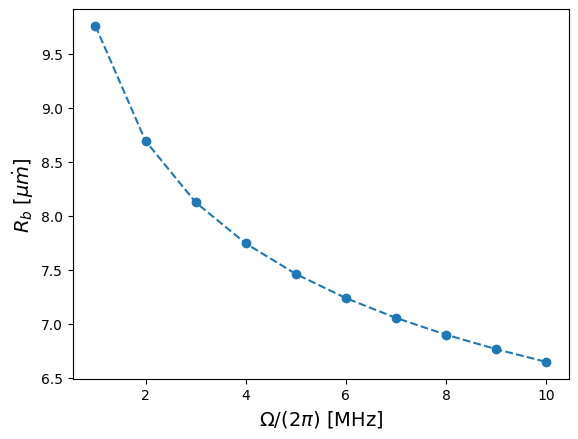

In [2]:
# Plot the Rydberg blockade radius as a function of the Rabi frequency.
Rabi = np.linspace(1, 10, 10)
R_blockade = [
    Chadoq2.rydberg_blockade_radius(2.0 * np.pi * rabi) for rabi in Rabi
]

plt.figure()
plt.plot(Rabi, R_blockade, "--o")
plt.xlabel(r"$\Omega/(2\pi)$ [MHz]", fontsize=14)
plt.ylabel(r"$R_b$ [$\mu\.m$]", fontsize=14)
plt.show()

In [3]:
# Define hardware-aware waveform utilities and quantum gate/feature-map building blocks.
max_amplitude = 62.83


def _resolve_device_channel_name(seq, channel_name):
    if channel_name in ACTIVE_SIM_DEVICE.channels:
        return channel_name

    if seq is not None:
        try:
            declared_channel = seq.declared_channels.get(channel_name)
        except Exception:
            declared_channel = None

        if declared_channel is not None:
            for dev_name, dev_channel in ACTIVE_SIM_DEVICE.channels.items():
                if declared_channel == dev_channel:
                    return dev_name

    alias_map = {"ram": "raman_local", "ryd": "rydberg_local"}
    mapped = alias_map.get(channel_name)
    if mapped in ACTIVE_SIM_DEVICE.channels:
        return mapped

    raise KeyError(
        f"Cannot resolve channel '{channel_name}' on device {ACTIVE_SIM_DEVICE.name}."
    )


def _align_duration_to_clock(duration_ns, channel_name, seq=None):
    device_channel_name = _resolve_device_channel_name(seq, channel_name)
    channel = ACTIVE_SIM_DEVICE.channels[device_channel_name]
    clock_period = int(channel.clock_period)
    min_duration = int(channel.min_duration)
    duration_ns = max(int(duration_ns), min_duration)
    return int(np.ceil(duration_ns / clock_period) * clock_period)


def _blackman_waveform_hw_aware(max_val, area, channel_name, seq=None):
    wf = BlackmanWaveform.from_max_val(max_val, area)
    if not QUANTIZE_PULSES_TO_CLOCK:
        return wf
    aligned_duration = _align_duration_to_clock(wf.duration, channel_name, seq=seq)
    if aligned_duration != wf.duration:
        wf = wf.change_duration(aligned_duration)
    return wf


def U_gate_ZXZ(gamma,theta,phi,seq,channelName,qubit):
    seq.target(qubit,channelName)
    phi = phi%(2*np.pi);
    theta = theta%(2*np.pi);
    gamma = gamma%(2*np.pi);
    p = Pulse.ConstantDetuning(
        _blackman_waveform_hw_aware(max_amplitude, theta, channelName, seq=seq), detuning=0, phase=phi, post_phase_shift=(gamma+phi)%(2*np.pi)
    )
    seq.add(p,channelName)


def RX_gate(theta,seq,channelName,qubit):
    theta = theta%(2*np.pi);
    U_gate_ZXZ(0,theta,0,seq,channelName,qubit);

def RZ_gate(phi,seq,channelName,qubit):
    seq.phase_shift(phi, qubit, basis="digital")


def X_gate(seq,channelName,qubit):
    RX_gate(np.pi,seq,channelName,qubit)
def Z_gate(seq,channelName,qubit):
    RZ_gate(np.pi,seq,channelName,qubit)
def H_gate(seq,channelName,qubit):
    U_gate_ZXZ(np.pi/2,np.pi/2,np.pi/2,seq,channelName,qubit)



pi_pulse = Pulse.ConstantDetuning(
    _blackman_waveform_hw_aware(max_amplitude, np.pi, "rydberg_local"),
    0,
    0,
)
max_val = ACTIVE_SIM_DEVICE.rabi_from_blockade(10)

two_pi_pulse = Pulse.ConstantDetuning(
    amplitude=_blackman_waveform_hw_aware(
        max_val=max_val,
        area=2*np.pi,
        channel_name="rydberg_local",
    ),
    detuning=0,
    phase=0,
)

def CZ_gate(seq,controlQubit,targetQubit,digitalChannelName,rydbergChannelName):
    seq.target(controlQubit,rydbergChannelName)


    seq.align(digitalChannelName, rydbergChannelName)


    seq.add(pi_pulse, rydbergChannelName)

    seq.align(digitalChannelName,rydbergChannelName)
    seq.target(targetQubit,rydbergChannelName)
    seq.add(two_pi_pulse, rydbergChannelName)
    seq.align(digitalChannelName,rydbergChannelName)

    seq.target(controlQubit, rydbergChannelName)
    seq.add(pi_pulse, rydbergChannelName)

def CX_gate(seq,controlQubit,targetQubit,digitalChannelName,rydbergChannelName):
    seq.target(controlQubit,rydbergChannelName)


    seq.align(digitalChannelName, rydbergChannelName)


    seq.add(pi_pulse, rydbergChannelName)

    seq.align(digitalChannelName,rydbergChannelName)
    seq.target(targetQubit,digitalChannelName)
    H_gate(seq,digitalChannelName,targetQubit)
    seq.align(digitalChannelName,rydbergChannelName)
    seq.target(targetQubit,rydbergChannelName)
    seq.add(two_pi_pulse, rydbergChannelName)
    seq.align(digitalChannelName,rydbergChannelName)
    H_gate(seq,digitalChannelName,targetQubit)
    seq.align(digitalChannelName,rydbergChannelName)

    seq.target(controlQubit, rydbergChannelName)
    seq.add(pi_pulse, rydbergChannelName)

def ZZFeatureMap(seq,digitalChannelName,rydbergChannelName,x,nReps):


    #primo CX
    for i in range(0,nReps):
        H_gate(seq,digitalChannelName,"0")
        H_gate(seq,digitalChannelName,"1")
        H_gate(seq,digitalChannelName,"2")
        RZ_gate(2*x[0],seq,digitalChannelName,"0")
        RZ_gate(2*x[1],seq,digitalChannelName,"1")
        RZ_gate(2*x[2],seq,digitalChannelName,"2")
        CX_gate(seq,"0","1",digitalChannelName,rydbergChannelName)
        RZ_gate(2*(np.pi-x[0])*(np.pi-x[1]),seq,digitalChannelName,"1")
        CX_gate(seq,"0","1",digitalChannelName,rydbergChannelName)
        CX_gate(seq,"0","2",digitalChannelName,rydbergChannelName)
        RZ_gate(2*(np.pi-x[0])*(np.pi-x[2]),seq,digitalChannelName,"2")
        CX_gate(seq,"0","2",digitalChannelName,rydbergChannelName)
        CX_gate(seq,"1","2",digitalChannelName,rydbergChannelName)
        RZ_gate(2*(np.pi-x[1])*(np.pi-x[2]),seq,digitalChannelName,"2")
        CX_gate(seq,"1","2",digitalChannelName,rydbergChannelName)


def ZZFeatureMap_inv(seq,digitalChannelName,rydbergChannelName,x,nReps):


    #primo CX
    for i in range(0,nReps):
        CX_gate(seq,"1","2",digitalChannelName,rydbergChannelName)
        RZ_gate(-2*(np.pi-x[1])*(np.pi-x[2]),seq,digitalChannelName,"2")
        CX_gate(seq,"1","2",digitalChannelName,rydbergChannelName)
        CX_gate(seq,"0","2",digitalChannelName,rydbergChannelName)
        RZ_gate(-2*(np.pi-x[0])*(np.pi-x[2]),seq,digitalChannelName,"2")
        CX_gate(seq,"0","2",digitalChannelName,rydbergChannelName)
        CX_gate(seq,"0","1",digitalChannelName,rydbergChannelName)
        RZ_gate(-2*(np.pi-x[0])*(np.pi-x[1]),seq,digitalChannelName,"1")
        CX_gate(seq,"0","1",digitalChannelName,rydbergChannelName)
        RZ_gate(-2*x[2],seq,digitalChannelName,"2")
        RZ_gate(-2*x[1],seq,digitalChannelName,"1")
        RZ_gate(-2*x[0],seq,digitalChannelName,"0")
        H_gate(seq,digitalChannelName,"2")
        H_gate(seq,digitalChannelName,"1")
        H_gate(seq,digitalChannelName,"0")







def TwoLocal(seq,digitalChannelName,rydbergChannelName,nReps,parameters):
    for i in range(0,nReps):
        RX_gate(parameters[(i*6)+0],seq,digitalChannelName,"0")
        RX_gate(parameters[(i*6)+1],seq,digitalChannelName,"1")
        RX_gate(parameters[(i*6)+2],seq,digitalChannelName,"2")
        RZ_gate(parameters[(i*6)+3],seq,digitalChannelName,"0")
        RZ_gate(parameters[(i*6)+4],seq,digitalChannelName,"1")
        RZ_gate(parameters[(i*6)+5],seq,digitalChannelName,"2")
        CZ_gate(seq,"0","1",digitalChannelName,rydbergChannelName)
        CZ_gate(seq,"0","2",digitalChannelName,rydbergChannelName)
        CZ_gate(seq,"1","2",digitalChannelName,rydbergChannelName)



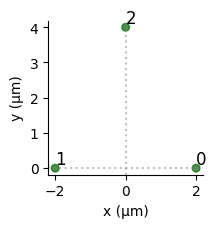

In [4]:
# Define the neutral-atom register geometry and display the qubit layout.
# Atom Register and Device
q_dict = {


    "2": np.array([0, 4]),
    "1": np.array([-2, 0.0]),
    "0": np.array([2,0])
}
reg = Register(q_dict)
reg.draw()



In [ ]:
# Generate the dataset directly with a 100x100x100 grid for visualization.
# This is for visualization only. 
# The training and test sets will still be generated with the default 20x20x20 grid.
algorithm_globals.random_seed = 10000

# Build a high-resolution variant of ad_hoc_data (count = 100) and use it directly.
_src = inspect.getsource(ad_hoc_data).replace(
    "count = 20  # coarseness of data separation",
    "count = 100  # high-res grid for visualization",
)
_local_ns = {}
exec(_src, ad_hoc_data.__globals__, _local_ns)
ad_hoc_data_hr = _local_ns["ad_hoc_data"]

train_data, train_labels, test_data, test_labels, sample_total_viz = ad_hoc_data_hr(
    training_size=20,
    test_size=10,
    n=3,
    gap=0.1,
    include_sample_total=True,
    one_hot=True,
)

# Build a custom color map for the 3D region plot.
cmap = {-1: 'green', 0: 'white', 1: 'blue'}

# Extract all grid coordinates and map each point to its class color.
x, y, z = np.where(np.abs(sample_total_viz) > -2)
colors = np.vectorize(cmap.get)(sample_total_viz[x, y, z])

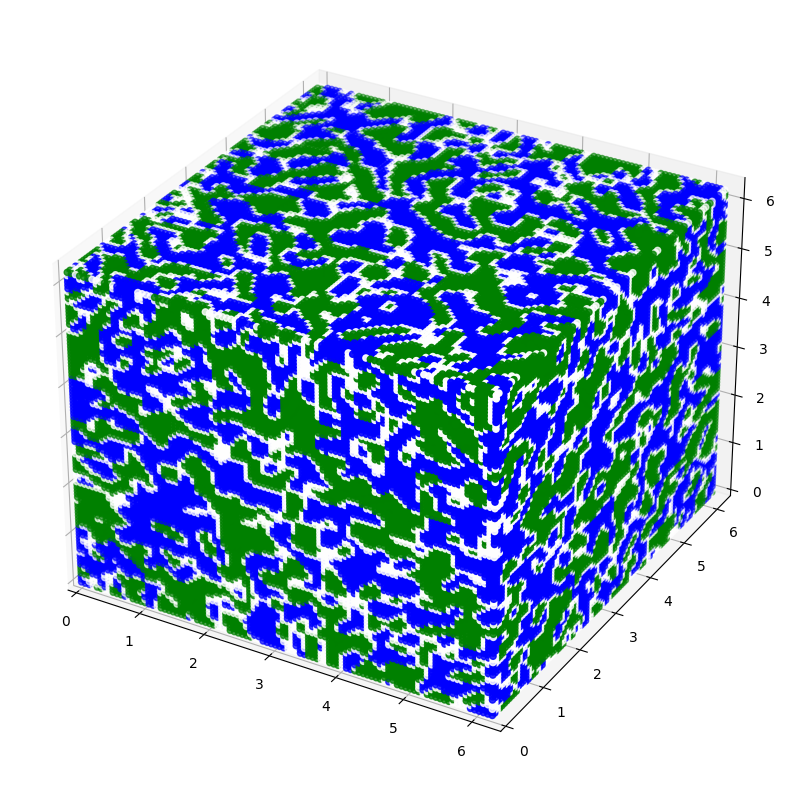

In [7]:
# Render and save the 3D visualization of the generated classification regions.
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim(0,2*np.pi)
ax.set_ylim(0,2*np.pi)
ax.set_zlim(0,2*np.pi)

N_viz = sample_total_viz.shape[0]
ax.scatter(x/N_viz*2*np.pi,y/N_viz*2*np.pi, z/N_viz*2*np.pi, c=colors)
plt.savefig("regions.png")
plt.show()

In [8]:
# Define a solver-safe parallel kernel evaluator with live progress reporting.
# Compute the training quantum kernel matrix KER in solver-safe parallel mode.
# We use processes (not threads) because ZVODE is not thread-safe.
# A single colored progress bar is updated in place, with one slot row per worker.
import multiprocessing as mp
import os
import time
from concurrent.futures import FIRST_COMPLETED, ProcessPoolExecutor, wait

from IPython.display import HTML, clear_output, display


_SEQ_PAYLOADS = None


def _kernel_worker_local(seq):
    simul = Simulation(seq)
    res = simul.run()
    counts = res.sample_final_state(N_samples=1000)
    prob = counts.get("000", 0) / sum(counts.values())
    return prob ** 2


def _kernel_worker_indexed(i_idx, j_idx):
    seq = _SEQ_PAYLOADS[i_idx][j_idx]
    return _kernel_worker_local(seq)


def _render_kernel_dashboard(done, total, slots, max_workers, title, start_time, recovered):
    progress = (done / total) if total else 1.0
    progress_pct = 100.0 * progress
    elapsed = time.time() - start_time
    active = sum(1 for slot in slots if slot is not None)

    slot_rows = []
    for idx, slot in enumerate(slots, start=1):
        if slot is None:
            slot_rows.append(f"<div style='color:#94a3b8;'>Slot {idx:02d}: idle</div>")
        else:
            iter_id, i_idx, j_idx = slot
            slot_rows.append(
                f"<div style='color:#fbbf24;'>Slot {idx:02d}: Iteration {iter_id} (i={i_idx}, j={j_idx})</div>"
            )

    html = f"""
<div style='font-family: Menlo, Monaco, Courier New, monospace; line-height:1.35;'>
  <div style='font-weight:700; color:#22d3ee; margin-bottom:6px;'>{title}</div>
  <div style='width:100%; max-width:940px; height:18px; border-radius:8px; overflow:hidden; border:1px solid #334155; background:#111827;'>
    <div style='height:100%; width:{progress_pct:.4f}%; background:linear-gradient(90deg, #22c55e, #06b6d4);'></div>
  </div>
  <div style='margin-top:6px; color:#e2e8f0;'>
    {done}/{total} ({progress_pct:.2f}%) | Active slots: {active}/{max_workers} | Recovered: {recovered} | Elapsed: {elapsed:.1f}s
  </div>
  <div style='margin-top:8px; max-width:940px; padding:8px; border-radius:8px; border:1px solid #1f2937; background:#020617;'>
    {''.join(slot_rows)}
  </div>
</div>
"""

    clear_output(wait=True)
    display(HTML(html))


def compute_kernel_matrix_parallel_solver_safe(sequences, n_x, n_y, title, max_workers=None):
    total = n_x * n_y
    if total == 0:
        return np.zeros((n_y, n_x), dtype=float)

    if max_workers is None:
        max_workers = min(total, os.cpu_count() or 1)
    max_workers = max(1, min(max_workers, total))

    matrix = np.zeros((n_y, n_x), dtype=float)
    slots = [None] * max_workers
    done = 0
    recovered = 0
    start_time = time.time()
    running = {}

    global _SEQ_PAYLOADS
    _SEQ_PAYLOADS = sequences

    task_generator = (
        (task_id, i_idx, j_idx)
        for task_id, (i_idx, j_idx) in enumerate(
            ((i_idx, j_idx) for i_idx in range(n_x) for j_idx in range(n_y)),
            start=1,
        )
    )

    def _submit_next(executor, slot_idx):
        try:
            task_id, i_idx, j_idx = next(task_generator)
        except StopIteration:
            return False
        fut = executor.submit(_kernel_worker_indexed, i_idx, j_idx)
        running[fut] = (slot_idx, task_id, i_idx, j_idx)
        slots[slot_idx] = (task_id, i_idx, j_idx)
        return True

    _render_kernel_dashboard(done, total, slots, max_workers, title, start_time, recovered)

    try:
        mp_ctx = mp.get_context("fork")
    except ValueError as exc:
        raise RuntimeError("'fork' multiprocessing context is required for solver-safe parallel mode.") from exc

    try:
        with ProcessPoolExecutor(max_workers=max_workers, mp_context=mp_ctx) as executor:
            for slot_idx in range(max_workers):
                if not _submit_next(executor, slot_idx):
                    break

            _render_kernel_dashboard(done, total, slots, max_workers, title, start_time, recovered)

            while running:
                done_futures, _ = wait(tuple(running.keys()), return_when=FIRST_COMPLETED)
                for fut in done_futures:
                    slot_idx, task_id, i_idx, j_idx = running.pop(fut)
                    try:
                        matrix[j_idx, i_idx] = fut.result()
                    except Exception:
                        # If one worker crashes, retry the same task immediately on the main process.
                        try:
                            matrix[j_idx, i_idx] = _kernel_worker_local(sequences[i_idx][j_idx])
                            recovered += 1
                        except Exception as retry_exc:
                            clear_output(wait=True)
                            raise RuntimeError(
                                f"Iteration {task_id} failed (i={i_idx}, j={j_idx}) even after local retry."
                            ) from retry_exc

                    done += 1
                    slots[slot_idx] = None
                    _submit_next(executor, slot_idx)
                    _render_kernel_dashboard(done, total, slots, max_workers, title, start_time, recovered)
    finally:
        _SEQ_PAYLOADS = None

    return matrix




In [ ]:
# Run the multi-seed QSVM vs RBF benchmark and save incremental results to CSV.
import csv
from pathlib import Path

import numpy as np
from qiskit.utils import algorithm_globals
from qiskit_machine_learning.datasets import ad_hoc_data
from sklearn.svm import SVC

# Fixed experimental settings (as requested).
TRAINING_SIZE = 20
TEST_SIZE = 10
N_FEATURES = 3
GAP = 0.1
N_RUNS = 30
DATASET_SEEDS = list(range(10000, 10000 + N_RUNS))

# N_samples is fixed inside _kernel_worker_local (currently 1000).
N_SAMPLES_PER_KERNEL_ENTRY = 1000

OUTPUT_CSV = Path("qsvm_vs_rbf_30runs_ttest.csv")
CSV_FIELDS = [
    "run_id",
    "dataset_seed",
    "accuracy_QSVM",
    "accuracy_RBF",
    "delta_accuracy",
]


def _build_pairwise_sequences(train_data_run, test_data_run):
    # Build all circuits needed to estimate the kernel matrices for one run.
    # Returns:
    # - train_sequences_run[i][j] for K(train_i, train_j)
    # - test_sequences_run[i][j] for K(train_i, test_j)
    x_data = train_data_run
    y_data = x_data
    train_sequences_run = [{} for _ in range(len(x_data))]

    # Train/train block: each sequence encodes U_phi(train_i) U_phi^dagger(train_j).
    for i_idx in range(len(x_data)):
        for j_idx in range(len(y_data)):
            seq_local = Sequence(reg, ACTIVE_SIM_DEVICE)
            seq_local.declare_channel("ram", "raman_local")
            seq_local.declare_channel("ryd", "rydberg_local")
            ZZFeatureMap(seq_local, "ram", "ryd", x_data[i_idx], 2)
            ZZFeatureMap_inv(seq_local, "ram", "ryd", y_data[j_idx], 2)
            train_sequences_run[i_idx][j_idx] = seq_local

    y_data = test_data_run
    test_sequences_run = [{} for _ in range(len(x_data))]

    # Train/test block: each sequence encodes U_phi(train_i) U_phi^dagger(test_j).
    for i_idx in range(len(x_data)):
        for j_idx in range(len(y_data)):
            seq_local = Sequence(reg, ACTIVE_SIM_DEVICE)
            seq_local.declare_channel("ram", "raman_local")
            seq_local.declare_channel("ryd", "rydberg_local")
            ZZFeatureMap(seq_local, "ram", "ryd", x_data[i_idx], 2)
            ZZFeatureMap_inv(seq_local, "ram", "ryd", y_data[j_idx], 2)
            test_sequences_run[i_idx][j_idx] = seq_local

    return train_sequences_run, test_sequences_run


def _read_existing_results(csv_path):
    if not csv_path.exists() or csv_path.stat().st_size == 0:
        return []

    rows = []
    with csv_path.open("r", newline="", encoding="utf-8") as f_in:
        reader = csv.DictReader(f_in)
        for row in reader:
            rows.append(
                {
                    "run_id": int(row["run_id"]),
                    "dataset_seed": int(row["dataset_seed"]),
                    "accuracy_QSVM": float(row["accuracy_QSVM"]),
                    "accuracy_RBF": float(row["accuracy_RBF"]),
                    "delta_accuracy": float(row["delta_accuracy"]),
                }
            )
    return rows


existing_rows = _read_existing_results(OUTPUT_CSV)
done_seed_set = {row["dataset_seed"] for row in existing_rows}
qsvm_accuracies = [row["accuracy_QSVM"] for row in existing_rows]
rbf_accuracies = [row["accuracy_RBF"] for row in existing_rows]

if not OUTPUT_CSV.exists() or OUTPUT_CSV.stat().st_size == 0:
    with OUTPUT_CSV.open("w", newline="", encoding="utf-8") as f_out:
        writer = csv.DictWriter(f_out, fieldnames=CSV_FIELDS)
        writer.writeheader()

print(f"Existing rows found in CSV: {len(existing_rows)}")

with OUTPUT_CSV.open("a", newline="", encoding="utf-8") as f_append:
    writer = csv.DictWriter(f_append, fieldnames=CSV_FIELDS)

    for run_id, dataset_seed in enumerate(DATASET_SEEDS, start=1):
        if int(dataset_seed) in done_seed_set:
            print(f"Run {run_id:02d}/{N_RUNS} | seed={dataset_seed} already present in CSV, skipped.")
            continue

        algorithm_globals.random_seed = int(dataset_seed)
        train_data_run, train_labels_run, test_data_run, test_labels_run, _ = ad_hoc_data(
            training_size=TRAINING_SIZE,
            test_size=TEST_SIZE,
            n=N_FEATURES,
            gap=GAP,
            include_sample_total=True,
            one_hot=True,
        )

        y_train_cls_run = (
            np.argmax(train_labels_run, axis=1)
            if np.ndim(train_labels_run) > 1
            else np.array(train_labels_run)
        )
        y_test_cls_run = (
            np.argmax(test_labels_run, axis=1)
            if np.ndim(test_labels_run) > 1
            else np.array(test_labels_run)
        )

        train_sequences_run, test_sequences_run = _build_pairwise_sequences(
            train_data_run, test_data_run
        )

        n_train_run = len(train_data_run)
        max_workers_run = min(n_train_run * n_train_run, os.cpu_count() or 1)

        KER_run = compute_kernel_matrix_parallel_solver_safe(
            sequences=train_sequences_run,
            n_x=n_train_run,
            n_y=n_train_run,
            title=f"Run {run_id}/{N_RUNS} - KER (seed={dataset_seed}, workers={max_workers_run})",
            max_workers=max_workers_run,
        )
        TEST_KER_run = compute_kernel_matrix_parallel_solver_safe(
            sequences=test_sequences_run,
            n_x=len(train_data_run),
            n_y=len(test_data_run),
            title=f"Run {run_id}/{N_RUNS} - TEST_KER (seed={dataset_seed}, workers={max_workers_run})",
            max_workers=max_workers_run,
        )

        qsvm_model_run = SVC(kernel="precomputed")
        qsvm_model_run.fit(KER_run, y_train_cls_run)
        accuracy_qsvm = float(qsvm_model_run.score(TEST_KER_run, y_test_cls_run))

        rbf_model_run = SVC(kernel="rbf")
        rbf_model_run.fit(train_data_run, y_train_cls_run)
        accuracy_rbf = float(rbf_model_run.score(test_data_run, y_test_cls_run))

        delta_accuracy = accuracy_qsvm - accuracy_rbf
        row = {
            "run_id": run_id,
            "dataset_seed": int(dataset_seed),
            "accuracy_QSVM": accuracy_qsvm,
            "accuracy_RBF": accuracy_rbf,
            "delta_accuracy": delta_accuracy,
        }

        writer.writerow(row)
        f_append.flush()
        os.fsync(f_append.fileno())

        done_seed_set.add(int(dataset_seed))
        qsvm_accuracies.append(accuracy_qsvm)
        rbf_accuracies.append(accuracy_rbf)

        print(
            f"Run {run_id:02d}/{N_RUNS} | seed={dataset_seed} | "
            f"QSVM={accuracy_qsvm:.4f} | RBF={accuracy_rbf:.4f} | delta={delta_accuracy:+.4f} | saved"
        )


print(f"Rows currently available: {len(done_seed_set)} / {N_RUNS}")
print(f"Fixed N_samples per kernel entry: {N_SAMPLES_PER_KERNEL_ENTRY}")

Run 30/30 | seed=10029 | QSVM=0.8000 | RBF=0.6000 | delta=+0.2000 | saved

Rows currently available: 30 / 30
Fixed N_samples per kernel entry: 1000


In [ ]:
# Load saved accuracies and run a paired Student t-test (QSVM vs RBF).
# Student t-test (paired): QSVM vs RBF accuracies read from CSV.
import csv
from pathlib import Path

import numpy as np
from scipy import stats

OUTPUT_CSV = Path("qsvm_vs_rbf_30runs_ttest.csv")

if not OUTPUT_CSV.exists() or OUTPUT_CSV.stat().st_size == 0:
    raise RuntimeError("CSV not found or empty. Run cell 19 first.")

qsvm_accuracies = []
rbf_accuracies = []

with OUTPUT_CSV.open("r", newline="", encoding="utf-8") as f_in:
    reader = csv.DictReader(f_in)
    for row in reader:
        qsvm_accuracies.append(float(row["accuracy_QSVM"]))
        rbf_accuracies.append(float(row["accuracy_RBF"]))

if len(qsvm_accuracies) < 2:
    raise RuntimeError("At least 2 paired runs are required for a t-test.")

qsvm_arr = np.array(qsvm_accuracies, dtype=float)
rbf_arr = np.array(rbf_accuracies, dtype=float)
ttest_result = stats.ttest_rel(qsvm_arr, rbf_arr)

print("\n=== Student paired t-test (QSVM vs RBF) ===")
print(f"runs: {len(qsvm_arr)}")
print(f"t-statistic: {ttest_result.statistic:.6f}")
print(f"p-value (two-sided): {ttest_result.pvalue:.6e}")
print(f"mean(QSVM): {np.mean(qsvm_arr):.6f}")
print(f"mean(RBF):  {np.mean(rbf_arr):.6f}")
print(f"mean(delta): {np.mean(qsvm_arr - rbf_arr):.6f}")


=== Student paired t-test (QSVM vs RBF) ===
runs: 30
t-statistic: 11.065181
p-value (two-sided): 6.327788e-12
mean(QSVM): 0.798333
mean(RBF):  0.528333
mean(delta): 0.270000
